# 🩺 Breast Cancer Histopathology Image Classification

## 📌 Problem Statement

Breast Cancer is one of the most common cancers among women worldwide.

The objective of this project is to build a Computer Vision based Deep Learning model that can classify Histopathology Images into:

- IDC Negative (Non Cancer)
- IDC Positive (Cancer)

## 🎯 Project Workflow

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Image Preprocessing
4. Data Augmentation
5. Train / Validation / Test Split
6. CNN Model Development
7. Model Training
8. Model Evaluation
9. Cancer Detection

## 📂 Dataset

Dataset: Breast Histopathology Images

Image Size: 50 × 50 Pixels

Classes:

- Class 0 → Non Cancer
- Class 1 → Cancer

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import glob
import os

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

# 📂 Dataset Loading

In this step we will load all histopathology images from the Kaggle dataset using the glob module.

In [2]:
from tqdm import tqdm
import glob
import random

class_0 = []
class_1 = []

# Non-Cancer Images
for img in tqdm(
    glob.iglob(
        "/kaggle/input/datasets/paultimothymooney/breast-histopathology-images/**/*class0.png",
        recursive=True
    ),
    desc="Loading Non-Cancer Images"
):

    class_0.append(img)

    if len(class_0) == 28495:
        break


# Cancer Images
for img in tqdm(
    glob.iglob(
        "/kaggle/input/datasets/paultimothymooney/breast-histopathology-images/**/*class1.png",
        recursive=True
    ),
    desc="Loading Cancer Images"
):

    class_1.append(img)

    if len(class_1) == 27384:
        break


# Merge and Shuffle
breast_img = class_0 + class_1
random.shuffle(breast_img)

print("\nDataset Summary")
print("----------------")
print("Non Cancer Images :", len(class_0))
print("Cancer Images     :", len(class_1))
print("Total Images      :", len(breast_img))

Loading Non-Cancer Images: 28494it [01:10, 406.35it/s]
Loading Cancer Images: 27383it [04:21, 104.55it/s] 


Dataset Summary
----------------
Non Cancer Images : 28495
Cancer Images     : 27384
Total Images      : 55879


# Creating Dataset DataFrame

Each image filename contains its class label.

Examples:

10295_idx5_x1351_y1101_class0.png
10295_idx5_x1351_y1151_class1.png

Where:

- class0 → Non Cancer
- class1 → Cancer

We will extract labels from filenames and create a DataFrame.

In [16]:
data = []

for img in class_0:
    data.append([img, 0])

for img in class_1:
    data.append([img, 1])

random.shuffle(data)

df = pd.DataFrame(
    data,
    columns=["path","label"]
)

df.head()

,path,label
0,/kaggle/input/datasets/paultimothymooney/breas...,0
1,/kaggle/input/datasets/paultimothymooney/breas...,0
2,/kaggle/input/datasets/paultimothymooney/breas...,1
3,/kaggle/input/datasets/paultimothymooney/breas...,1
4,/kaggle/input/datasets/paultimothymooney/breas...,0


# Dataset Overview

Let's inspect:

- Total images
- Number of columns
- Data types
- Missing values

In [17]:
print("Dataset Shape:", df.shape)

Dataset Shape: (55879, 2)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55879 entries, 0 to 55878
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    55879 non-null  object
 1   label   55879 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 873.2+ KB


# Class Distribution Analysis

Before training any Deep Learning model, it is important to understand whether the dataset is balanced or imbalanced.

In [19]:
df["label"].value_counts()

label
0    28495
1    27384
Name: count, dtype: int64

# Count Plot

Visual representation of Cancer and Non-Cancer samples.

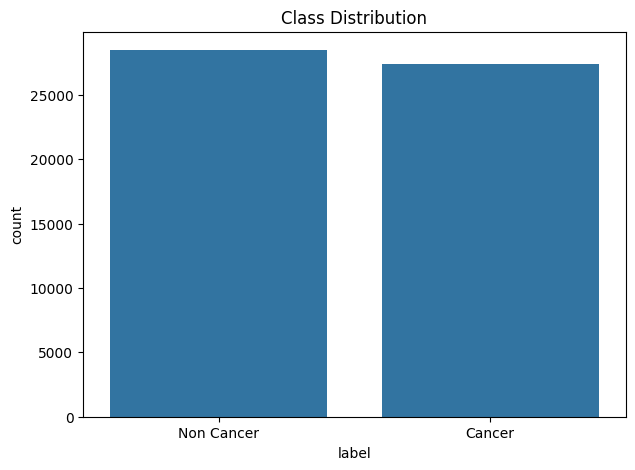

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.countplot(
    x=df["label"]
)

plt.xticks(
    [0,1],
    ["Non Cancer","Cancer"]
)

plt.title("Class Distribution")

plt.show()

# Pie Chart Representation

Percentage distribution of both classes.

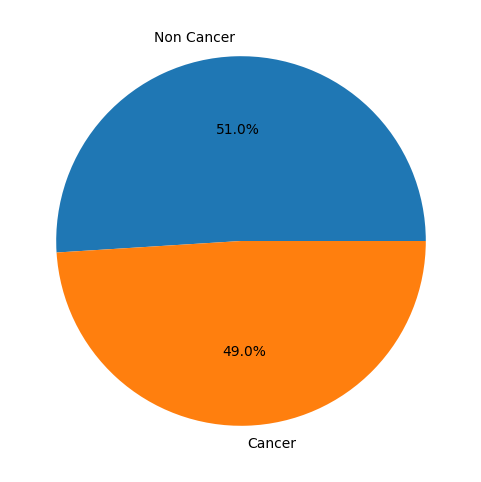

In [21]:
df["label"].value_counts().plot.pie(
    autopct="%1.1f%%",
    labels=["Non Cancer","Cancer"],
    figsize=(6,6)
)

plt.ylabel("")
plt.show()

# Random Histopathology Samples

Visualizing random images from the dataset.

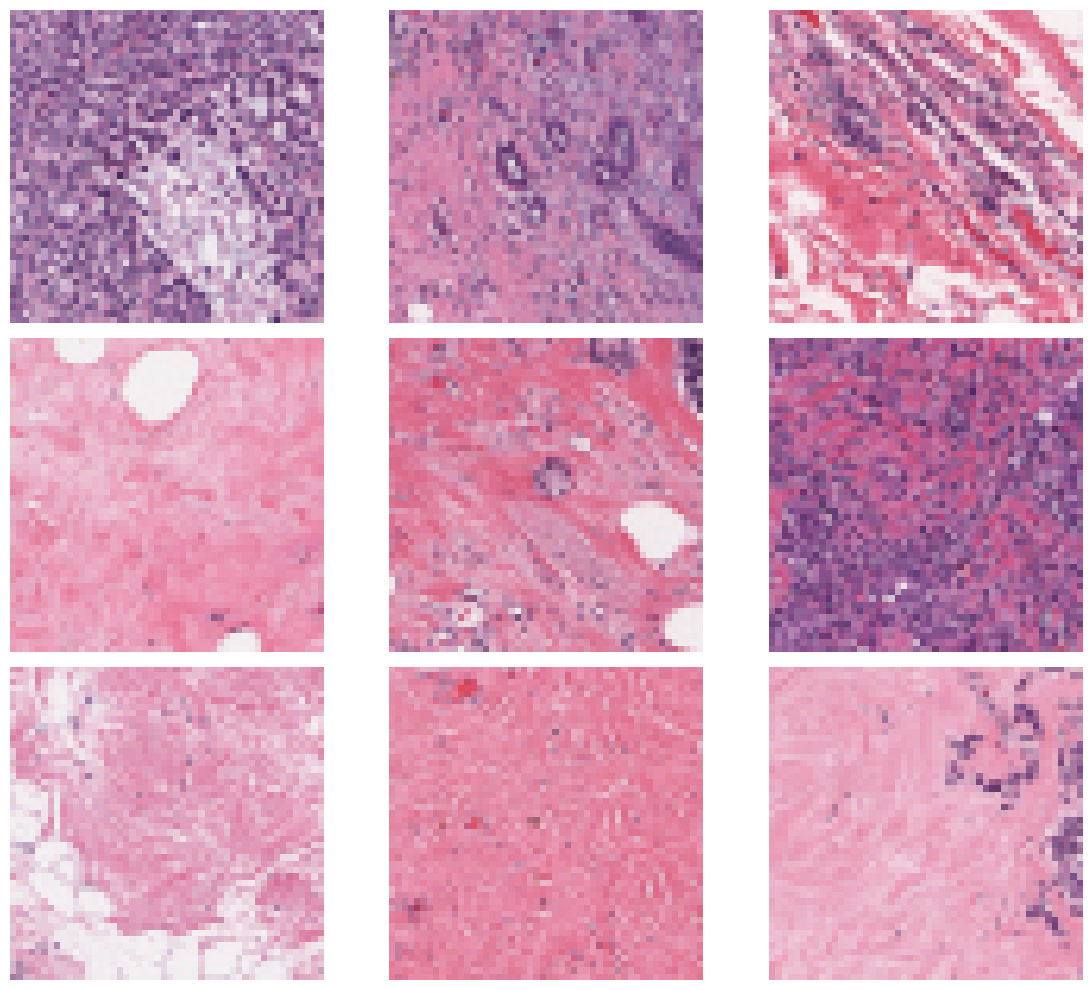

In [22]:
import cv2
import random

plt.figure(figsize=(12,10))

sample_images = random.sample(
    list(df["path"]),
    9
)

for i,path in enumerate(sample_images):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()
plt.show()

# Cancer vs Non-Cancer Visualization

Comparing one cancer image and one non-cancer image.

In [23]:
cancer_img = df[df["label"]==1].iloc[0]["path"]

non_cancer_img = df[df["label"]==0].iloc[0]["path"]

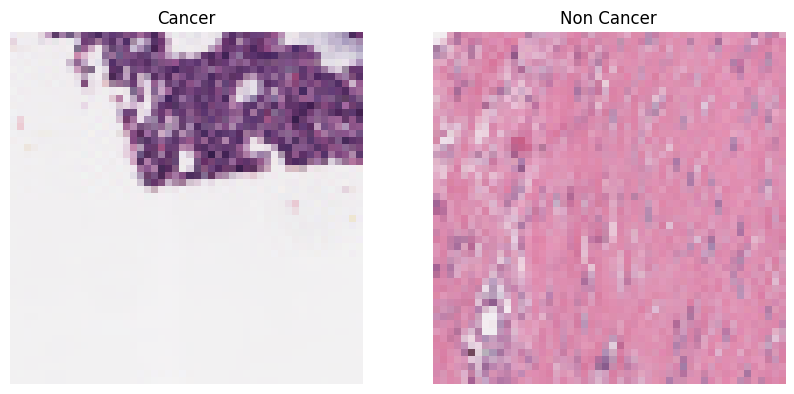

In [24]:
img1 = cv2.imread(cancer_img)
img1 = cv2.cvtColor(img1,cv2.COLOR_BGR2RGB)

img2 = cv2.imread(non_cancer_img)
img2 = cv2.cvtColor(img2,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Cancer")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Non Cancer")
plt.axis("off")

plt.show()

# Image Shape Analysis

Checking image dimensions to ensure consistency across the dataset.

In [25]:
img = cv2.imread(df["path"][0])

print("Image Shape:", img.shape)

Image Shape: (50, 50, 3)


# Pixel Statistics

Analyzing image pixel intensity values.

In [26]:
img = cv2.imread(df["path"][0])

print("Minimum Pixel :", img.min())
print("Maximum Pixel :", img.max())
print("Mean Pixel    :", img.mean())

Minimum Pixel : 71
Maximum Pixel : 244
Mean Pixel    : 179.9248


# 🖼️ Image Preprocessing

To improve image quality and enhance important tissue structures, the following preprocessing steps are applied:

- Resize Images to 128×128
- Convert RGB to LAB Color Space
- Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
- Normalize Pixel Values

In [61]:
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 64

def preprocess_image(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    img = img.astype(np.float32)

    img = preprocess_input(img)

    return img

In [62]:
X = []
y = []

for path, label in tqdm(
    zip(df.path, df.label),
    total=len(df),
    desc="Preprocessing Images"
):

    X.append(preprocess_image(path))
    y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

Preprocessing Images: 100%|██████████| 55879/55879 [01:41<00:00, 549.16it/s]


(55879, 64, 64, 3)
(55879,)


# 🖼️ Original vs Preprocessed Images

To improve the quality of histopathology images, preprocessing techniques were applied.

The preprocessing pipeline includes:

- Image Resizing (128 × 128)
- RGB to LAB Color Space Conversion
- CLAHE (Contrast Limited Adaptive Histogram Equalization)
- Pixel Normalization

The figure below compares the original image with its corresponding preprocessed image.

It can be observed that preprocessing enhances tissue contrast and highlights important microscopic structures, which helps the CNN model learn more discriminative features.

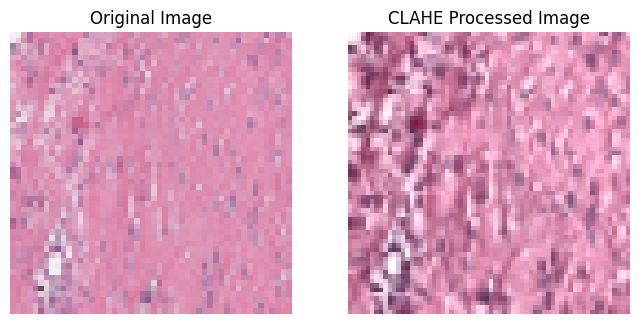

In [65]:
path = df.iloc[0]["path"]

# Original Image
original = cv2.imread(path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Only CLAHE + Resize for visualization
processed = cv2.resize(original, (64, 64))

lab = cv2.cvtColor(processed, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

cl = clahe.apply(l)

limg = cv2.merge((cl, a, b))

processed = cv2.cvtColor(
    limg,
    cv2.COLOR_LAB2RGB
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed)
plt.title("CLAHE Processed Image")
plt.axis("off")

plt.show()

# Train Validation Test Split

Machine Learning models should never be trained and tested on the same data.

We split the dataset into:

- Training Set → 70%
- Validation Set → 15%
- Test Set → 15%

Training Set:
Used for learning patterns.

Validation Set:
Used for hyperparameter tuning.

Test Set:
Used for final evaluation.

In [66]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [67]:
print("Training Images   :", len(train_df))
print("Validation Images :", len(val_df))
print("Test Images       :", len(test_df))

Training Images   : 39115
Validation Images : 8382
Test Images       : 8382


# Verify Class Distribution

Stratified sampling ensures that the class ratio remains similar in all datasets.

In [68]:
print("Train")
print(train_df["label"].value_counts())

print("\nValidation")
print(val_df["label"].value_counts())

print("\nTest")
print(test_df["label"].value_counts())

Train
label
0    19946
1    19169
Name: count, dtype: int64

Validation
label
0    4274
1    4108
Name: count, dtype: int64

Test
label
0    4275
1    4107
Name: count, dtype: int64


# Test Preprocessing

Visual inspection of processed image.

In [69]:
sample_img = preprocess_image(
    train_df.iloc[0]["path"]
)

print(sample_img.shape)
print(sample_img.min())
print(sample_img.max())

(64, 64, 3)
62.0
236.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [62.0..236.0].


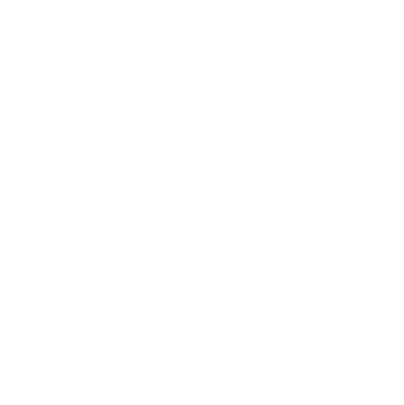

In [70]:
plt.figure(figsize=(5,5))

plt.imshow(sample_img)

plt.axis("off")

plt.show()

# Create Numpy Arrays

Convert image paths into numerical tensors for CNN training.

In [71]:
X_train = []
y_train = []

In [72]:
from tqdm import tqdm

for _, row in tqdm(train_df.iterrows(),
                   total=len(train_df)):

    X_train.append(
        preprocess_image(row["path"])
    )

    y_train.append(
        row["label"]
    )

100%|██████████| 39115/39115 [01:00<00:00, 645.25it/s]


In [73]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [74]:
print(X_train.shape)
print(y_train.shape)

(39115, 64, 64, 3)
(39115,)


In [75]:
X_val = []
y_val = []

for _, row in tqdm(val_df.iterrows(),
                   total=len(val_df)):

    X_val.append(
        preprocess_image(row["path"])
    )

    y_val.append(
        row["label"]
    )

X_val = np.array(X_val)
y_val = np.array(y_val)

print(X_val.shape)
print(y_val.shape)

100%|██████████| 8382/8382 [00:13<00:00, 625.98it/s]


(8382, 64, 64, 3)
(8382,)


In [76]:
X_test = []
y_test = []

for _, row in tqdm(test_df.iterrows(),
                   total=len(test_df)):

    X_test.append(
        preprocess_image(row["path"])
    )

    y_test.append(
        row["label"]
    )

X_test = np.array(X_test)
y_test = np.array(y_test)

print(X_test.shape)
print(y_test.shape)

100%|██████████| 8382/8382 [00:13<00:00, 626.93it/s]


(8382, 64, 64, 3)
(8382,)


# Data Augmentation

To improve model generalization we apply:

- Rotation
- Zoom
- Horizontal Flip
- Width Shift
- Height Shift

In [77]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
)

# Convolutional Neural Network (CNN)

CNN is specially designed for image data.

Architecture:

Input Image (50x50x3)

↓

Conv2D + ReLU

↓

MaxPooling

↓

Conv2D + ReLU

↓

MaxPooling

↓

Conv2D + ReLU

↓

MaxPooling

↓

Flatten

↓

Dense

↓

Dropout

↓

Output Layer (Sigmoid)

In [78]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

In [79]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

base_model.trainable = False

In [80]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])



# Model Summary

Let's inspect:

- Layers
- Output Shapes
- Trainable Parameters

In [81]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Compile Model

Optimizer : Adam

Loss Function : Binary Crossentropy

Metric : Accuracy

In [82]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [83]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_breast_cancer_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# 🛑 Early Stopping and Model Checkpoint

To prevent overfitting and save the best model during training:

- **EarlyStopping** stops training when validation loss stops improving.
- **ModelCheckpoint** saves the best model automatically.

In [84]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_val, return_counts=True))

(array([0, 1]), array([19946, 19169]))
(array([0, 1]), array([4274, 4108]))


In [85]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=5,
    batch_size=32,

    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/20
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7641 - loss: 0.5007
Epoch 1: val_loss improved from None to 0.41590, saving model to best_breast_cancer_model.keras

Epoch 1: finished saving model to best_breast_cancer_model.keras
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 53s 27ms/step - accuracy: 0.7798 - loss: 0.4754 - val_accuracy: 0.8077 - val_loss: 0.4159
Epoch 2/20
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7956 - loss: 0.4416
Epoch 2: val_loss improved from 0.41590 to 0.41485, saving model to best_breast_cancer_model.keras

Epoch 2: finished saving model to best_breast_cancer_model.keras
1223/1223 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7977 - loss: 0.4420 - val_accuracy: 0.8095 - val_loss: 0.4148
Epoch 3/20
1222/1223 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8041 - loss: 0.4333
Epoch 3: val_loss improved from 0.41485 to 0.40433, saving model to best_breast_cancer_model.keras

Epoch 3: finished saving model to best_breast_cancer_model.keras
1

# Training History

Visualizing:

- Accuracy
- Validation Accuracy
- Loss
- Validation Loss

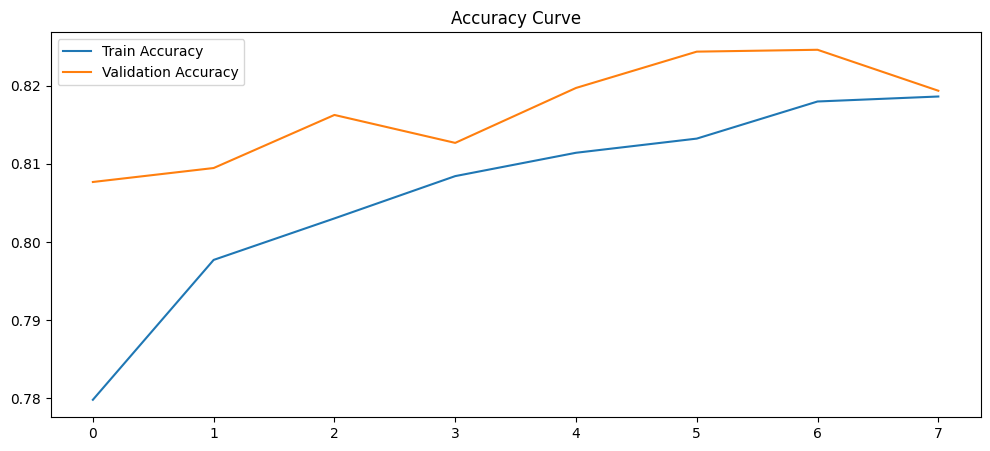

In [86]:
plt.figure(figsize=(12,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()

plt.title("Accuracy Curve")

plt.show()

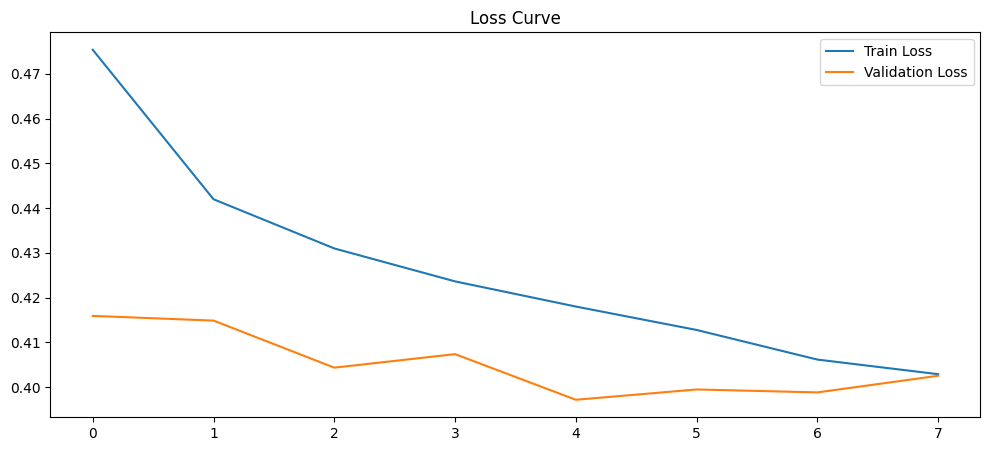

In [87]:
plt.figure(figsize=(12,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()

plt.title("Loss Curve")

plt.show()

 # 📊 Confusion Matrix

A confusion matrix helps us understand the model's classification performance.

262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step


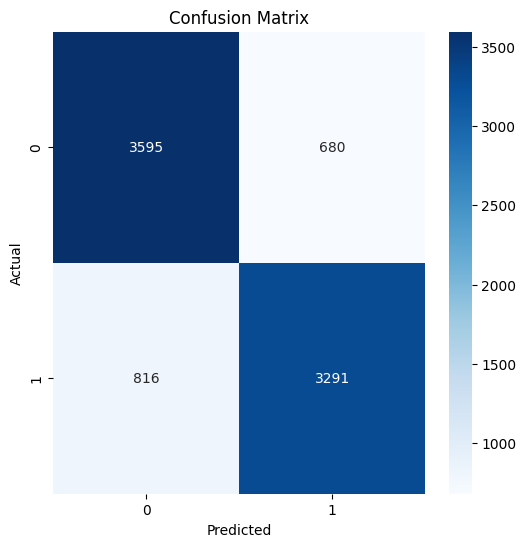

In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# 📈 Classification Report

The classification report provides Precision, Recall and F1-Score.

In [89]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      4275
           1       0.83      0.80      0.81      4107

    accuracy                           0.82      8382
   macro avg       0.82      0.82      0.82      8382
weighted avg       0.82      0.82      0.82      8382



 # 📉 ROC Curve

ROC Curve evaluates the classifier performance at different thresholds.

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


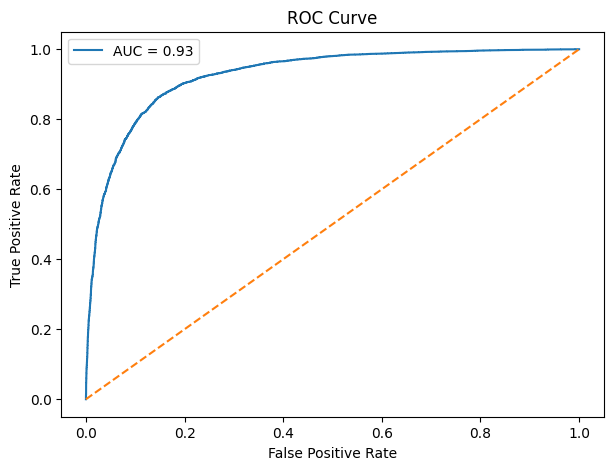

In [80]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test)

fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()